#Importing Libraries

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Load Dataset

In [64]:
df = pd.read_csv('credit_data.csv')
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [65]:
df.info()

print('--------')

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43818 entries, 0 to 43817
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        43818 non-null  object 
 1   Customer_ID               43818 non-null  object 
 2   Month                     43818 non-null  object 
 3   Name                      39459 non-null  object 
 4   Age                       43818 non-null  object 
 5   SSN                       43818 non-null  object 
 6   Occupation                43818 non-null  object 
 7   Annual_Income             43818 non-null  object 
 8   Monthly_Inhand_Salary     37270 non-null  float64
 9   Num_Bank_Accounts         43818 non-null  int64  
 10  Num_Credit_Card           43818 non-null  int64  
 11  Interest_Rate             43818 non-null  int64  
 12  Num_of_Loan               43818 non-null  object 
 13  Type_of_Loan              38872 non-null  object 
 14  Delay_

In [66]:
print(df.isnull().sum())

ID                             0
Customer_ID                    0
Month                          0
Name                        4359
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       6548
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                4946
Delay_from_due_date            0
Num_of_Delayed_Payment      3085
Changed_Credit_Limit           0
Num_Credit_Inquiries         840
Credit_Mix                     1
Outstanding_Debt               1
Credit_Utilization_Ratio       1
Credit_History_Age          3986
Payment_of_Min_Amount          1
Total_EMI_per_month            1
Amount_invested_monthly     1940
Payment_Behaviour              1
Monthly_Balance              563
Credit_Score                   1
dtype: int64


# Data Cleaning and Pre-Processing

In [67]:
df = df.drop(['ID', 'Customer_ID', 'Name', 'SSN'], axis = 1) # dropping irrelevant columns
display(df.head())

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,January,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,February,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,March,-500,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,April,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,May,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [68]:
# Convert "Age" column to numeric, coercing errors
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

#Calculating median age
median_age = df['Age'].median()

# Defining outliers boundaries
lower_bound = 0
upper_bound = 100

# Replacing outliers with median age
df['Age'] = np.where((df['Age'] < lower_bound) | (df['Age'] > upper_bound), median_age, df['Age'])

# Impute missing values in 'Age' with the median
df['Age'] = df['Age'].fillna(median_age)

# Displaying updated age column information
display(df['Age'].describe())

,Age
count,43818.000000
mean,33.185746
std,10.291842
min,14.000000
25%,25.000000
50%,33.000000
75%,41.000000
max,100.000000


In [69]:
# Replacing '_' with 'Unknown' in "Credi_Mix" Column
df['Credit_Mix'] = df['Credit_Mix'].str.replace('_', 'Unknown')
display(df['Credit_Mix'].value_counts())

,count
Credit_Mix,
Standard,15610
Good,10881
Unknown,8907
Bad,8419


In [70]:
# Fill missing values with a placeholder
df['Credit_History_Age'] = df['Credit_History_Age'].fillna('0 Years and 0 Months')

# Extracting years and month using string manipulation
df['Years'] = df['Credit_History_Age'].apply(lambda x: int(x.split(' ')[0]))
df['Months'] = df['Credit_History_Age'].apply(lambda x: int(x.split(' ')[3]))

# Converting years and months to total months
df['Credit_History_Age'] = df['Years'] * 12 + df['Months']

# Converting to numeric type
df['Credit_History_Age'] = pd.to_numeric(df['Credit_History_Age'])

# Dropping the temporary 'Years' and 'Months' columns
df.drop(['Years', 'Months'], axis=1, inplace=True)

# Displaying the first few rows and info to verify the changes
display(df.head())
display(df.isnull().sum())

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,January,23.0,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Unknown,809.98,26.822620,265,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,February,23.0,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,31.944960,0,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,March,33.0,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,28.609352,267,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,April,23.0,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,31.377862,268,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,May,23.0,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,24.797347,269,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


,0
Month,0
Age,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,6548
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Type_of_Loan,4946


In [71]:
# Handling missing values in "Type_of_Loan" by filling with 'Not Specified'
df['Type_of_Loan'] = df['Type_of_Loan'].fillna('Not Specified')

#Displaying updated 'Type_of_Loan' column information
display(df['Type_of_Loan'].value_counts())

,count
Type_of_Loan,
Not Specified,5530
Credit-Builder Loan,568
Debt Consolidation Loan,528
Payday Loan,512
Mortgage Loan,504
...,...
"Not Specified, Debt Consolidation Loan, Home Equity Loan, Not Specified, Mortgage Loan, Personal Loan, and Personal Loan",8
"Payday Loan, Mortgage Loan, Auto Loan, Debt Consolidation Loan, and Credit-Builder Loan",8
"Mortgage Loan, Mortgage Loan, Not Specified, and Personal Loan",8


In [72]:
# Getting all unique loan types
unique_loan_types = df['Type_of_Loan'].str.split(', ').explode().unique()

# Removing 'Not Specified' if it exists in the unique types
if 'Not Specified' in unique_loan_types:
    unique_loan_types = unique_loan_types[unique_loan_types != 'Not Specified']

# Creating binary columns for each unique loan type
for loan_type in unique_loan_types:
  df[loan_type.replace(' ', '_')] = df['Type_of_Loan'].apply(lambda x: 1 if loan_type in x else 0)

# Dropping the original 'Type_of_Loan' column
df.drop('Type_of_Loan', axis = 1, inplace = True)

# Displaying the first few rows of the updated DataFrame
display(df.head())

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Debt_Consolidation_Loan,and_Auto_Loan,and_Payday_Loan,Payday_Loan,Student_Loan,and_Personal_Loan,Home_Equity_Loan,Mortgage_Loan,and_Debt_Consolidation_Loan,and_Credit-Builder_Loan
0,January,23.0,Scientist,19114.12,1824.843333,3,4,3,4,3,...,0,0,0,0,0,0,1,0,0,0
1,February,23.0,Scientist,19114.12,NaN,3,4,3,4,-1,...,0,0,0,0,0,0,1,0,0,0
2,March,33.0,Scientist,19114.12,NaN,3,4,3,4,3,...,0,0,0,0,0,0,1,0,0,0
3,April,23.0,Scientist,19114.12,NaN,3,4,3,4,5,...,0,0,0,0,0,0,1,0,0,0
4,May,23.0,Scientist,19114.12,1824.843333,3,4,3,4,6,...,0,0,0,0,0,0,1,0,0,0


In [73]:
# Clean and convert specified numeric columns to numeric, coercing errors to NaN
cols_to_clean_and_convert = ['Monthly_Inhand_Salary', 'Num_of_Delayed_Payment', 'Num_Credit_Inquiries', 'Amount_invested_monthly', 'Monthly_Balance', 'Annual_Income', 'Changed_Credit_Limit', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Num_of_Loan', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date']

for col in cols_to_clean_and_convert:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace(r'[^\d.-]+', '', regex=True) # Remove non-numeric characters except decimals and hyphens
        df[col] = pd.to_numeric(df[col], errors='coerce') # Convert to numeric, coercing errors

# Calculate the median for each specified numeric column again (after cleaning)
median_monthly_inhand_salary = df['Monthly_Inhand_Salary'].median()
# Use mode for Num_of_Delayed_Payment as it might be count-like
mode_num_delayed_payment = df['Num_of_Delayed_Payment'].mode()[0]
median_num_credit_inquiries = df['Num_Credit_Inquiries'].median()
median_amount_invested_monthly = df['Amount_invested_monthly'].median()
median_monthly_balance = df['Monthly_Balance'].median()
median_annual_income = df['Annual_Income'].median()
median_changed_credit_limit = df['Changed_Credit_Limit'].median()
median_outstanding_debt = df['Outstanding_Debt'].median()
median_credit_utilization_ratio = df['Credit_Utilization_Ratio'].median()
median_total_emi_per_month = df['Total_EMI_per_month'].median()
median_num_of_loan = df['Num_of_Loan'].median()
median_num_bank_accounts = df['Num_Bank_Accounts'].median()
median_num_credit_card = df['Num_Credit_Card'].median()
median_interest_rate = df['Interest_Rate'].median()
median_delay_from_due_date = df['Delay_from_due_date'].median()


# Fill missing values in each column with its corresponding median/mode
df['Monthly_Inhand_Salary'] = df['Monthly_Inhand_Salary'].fillna(median_monthly_inhand_salary)
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].fillna(mode_num_delayed_payment)
df['Num_Credit_Inquiries'] = df['Num_Credit_Inquiries'].fillna(median_num_credit_inquiries)
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].fillna(median_amount_invested_monthly)
df['Monthly_Balance'] = df['Monthly_Balance'].fillna(median_monthly_balance)
df['Annual_Income'] = df['Annual_Income'].fillna(median_annual_income)
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].fillna(median_changed_credit_limit)
df['Outstanding_Debt'] = df['Outstanding_Debt'].fillna(median_outstanding_debt)
df['Credit_Utilization_Ratio'] = df['Credit_Utilization_Ratio'].fillna(median_credit_utilization_ratio)
df['Total_EMI_per_month'] = df['Total_EMI_per_month'].fillna(median_total_emi_per_month)
df['Num_of_Loan'] = df['Num_of_Loan'].fillna(median_num_of_loan)
df['Num_Bank_Accounts'] = df['Num_Bank_Accounts'].fillna(median_num_bank_accounts)
df['Num_Credit_Card'] = df['Num_Credit_Card'].fillna(median_num_credit_card)
df['Interest_Rate'] = df['Interest_Rate'].fillna(median_interest_rate)
df['Delay_from_due_date'] = df['Delay_from_due_date'].fillna(median_delay_from_due_date)

# Handle 'Payment_of_Min_Amount' separately: fill missing, then map
if 'Payment_of_Min_Amount' in df.columns:
    mode_payment_min_amount = df['Payment_of_Min_Amount'].mode()[0]
    df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].fillna(mode_payment_min_amount)
    df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].map({'No': 0, 'Yes': 1})
    # Ensure the column is numeric after mapping
    df['Payment_of_Min_Amount'] = pd.to_numeric(df['Payment_of_Min_Amount'], errors='coerce')


# Display the number of missing values for these columns after imputation
print(df[cols_to_clean_and_convert + ['Payment_of_Min_Amount']].isnull().sum())
print(df.isnull().sum())

Monthly_Inhand_Salary          0
Num_of_Delayed_Payment         0
Num_Credit_Inquiries           0
Amount_invested_monthly        0
Monthly_Balance                0
Annual_Income                  0
Changed_Credit_Limit           0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Total_EMI_per_month            0
Num_of_Loan                    0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Delay_from_due_date            0
Payment_of_Min_Amount       5262
dtype: int64
Month                             0
Age                               0
Occupation                        0
Annual_Income                     0
Monthly_Inhand_Salary             0
Num_Bank_Accounts                 0
Num_Credit_Card                   0
Interest_Rate                     0
Num_of_Loan                       0
Delay_from_due_date               0
Num_of_Delayed_Payment            0
Changed_Credit_Limit              0
Num_Credit_Inquiries       

In [74]:
# Identify categorical columns to encode
categorical_cols_to_encode = ['Month', 'Occupation', 'Credit_Mix', 'Payment_Behaviour']

# Perform one-hot encoding
df = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

# Display the first few rows and the columns of the updated DataFrame
display(df.head())
display(df.columns)

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Occupation________,Credit_Mix_Good,Credit_Mix_Standard,Credit_Mix_Unknown,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,23.0,19114.12,1824.843333,3,4,3,4,3,7.0,11.27,...,False,False,False,True,False,False,True,False,False,False
1,23.0,19114.12,3091.000000,3,4,3,4,-1,19.0,11.27,...,False,True,False,False,False,False,False,True,False,False
2,33.0,19114.12,3091.000000,3,4,3,4,3,7.0,9.31,...,False,True,False,False,False,False,False,False,True,False
3,23.0,19114.12,3091.000000,3,4,3,4,5,4.0,6.27,...,False,True,False,False,False,False,False,False,False,True
4,23.0,19114.12,1824.843333,3,4,3,4,6,19.0,11.27,...,False,True,False,False,False,True,False,False,False,False


Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Monthly_Balance', 'Credit_Score',
       'Auto_Loan', 'Credit-Builder_Loan', 'Personal_Loan',
       'and_Home_Equity_Loan', 'and_Not_Specified', 'and_Mortgage_Loan',
       'and_Student_Loan', 'Debt_Consolidation_Loan', 'and_Auto_Loan',
       'and_Payday_Loan', 'Payday_Loan', 'Student_Loan', 'and_Personal_Loan',
       'Home_Equity_Loan', 'Mortgage_Loan', 'and_Debt_Consolidation_Loan',
       'and_Credit-Builder_Loan', 'Month_August', 'Month_February',
       'Month_January', 'Month_July', 'Month_June', 'Month_March', 'Month_May',
       'Occupation_Architect', 'Occupation_Developer', 

In [75]:
# Mapping the 'Credit_Score' column to numerical values
credit_score_mapping = {'Poor': 0, 'Standard': 1, 'Good': 2}
df['Credit_Score'] = df['Credit_Score'].map(credit_score_mapping)

# Displaying the value counts of the updated 'Credit_Score' column
display(df['Credit_Score'].value_counts())

,count
Credit_Score,
1.0,23017
0.0,12939
2.0,7861


# Exploratory Data Analysis (EDA)

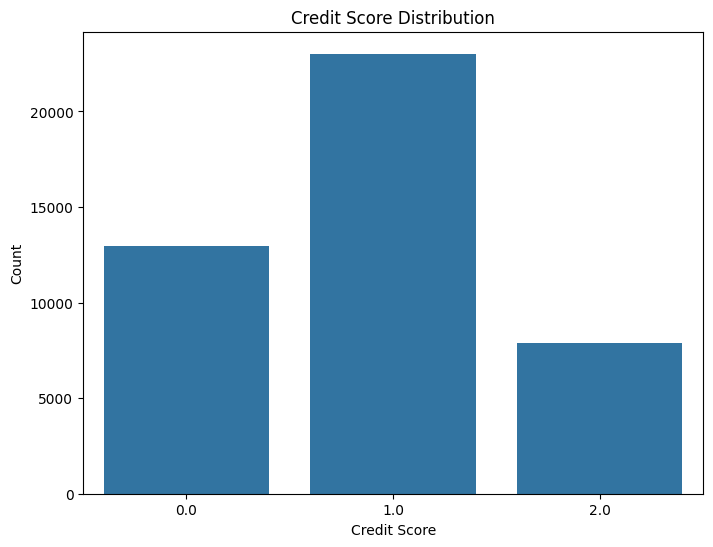

In [76]:
# Visualizing Target Distribution ('Credit_Score')
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Credit_Score')
plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.show()

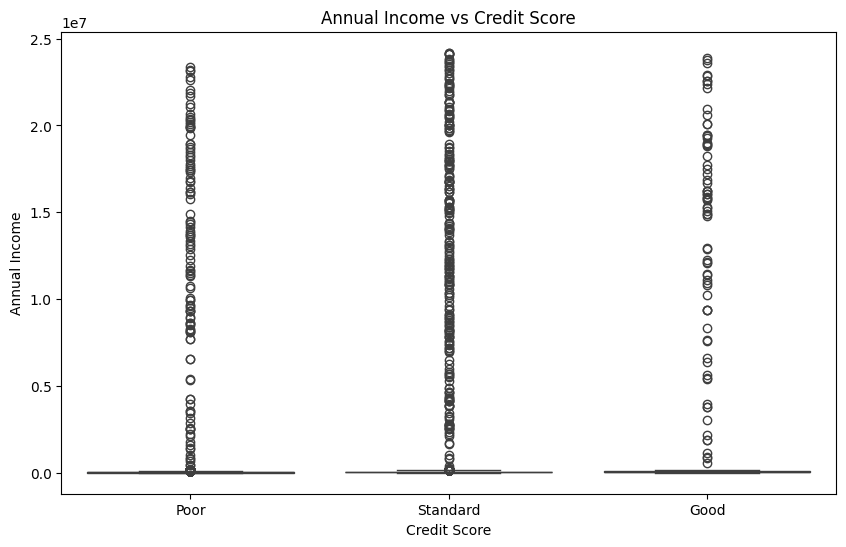

In [77]:
plt.figure(figsize = (10,6))
sns.boxplot(data = df, x = 'Credit_Score', y = 'Annual_Income')
plt.title('Annual Income vs Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Annual Income')
plt.xticks([0, 1, 2], ['Poor', 'Standard', 'Good'])
plt.show()

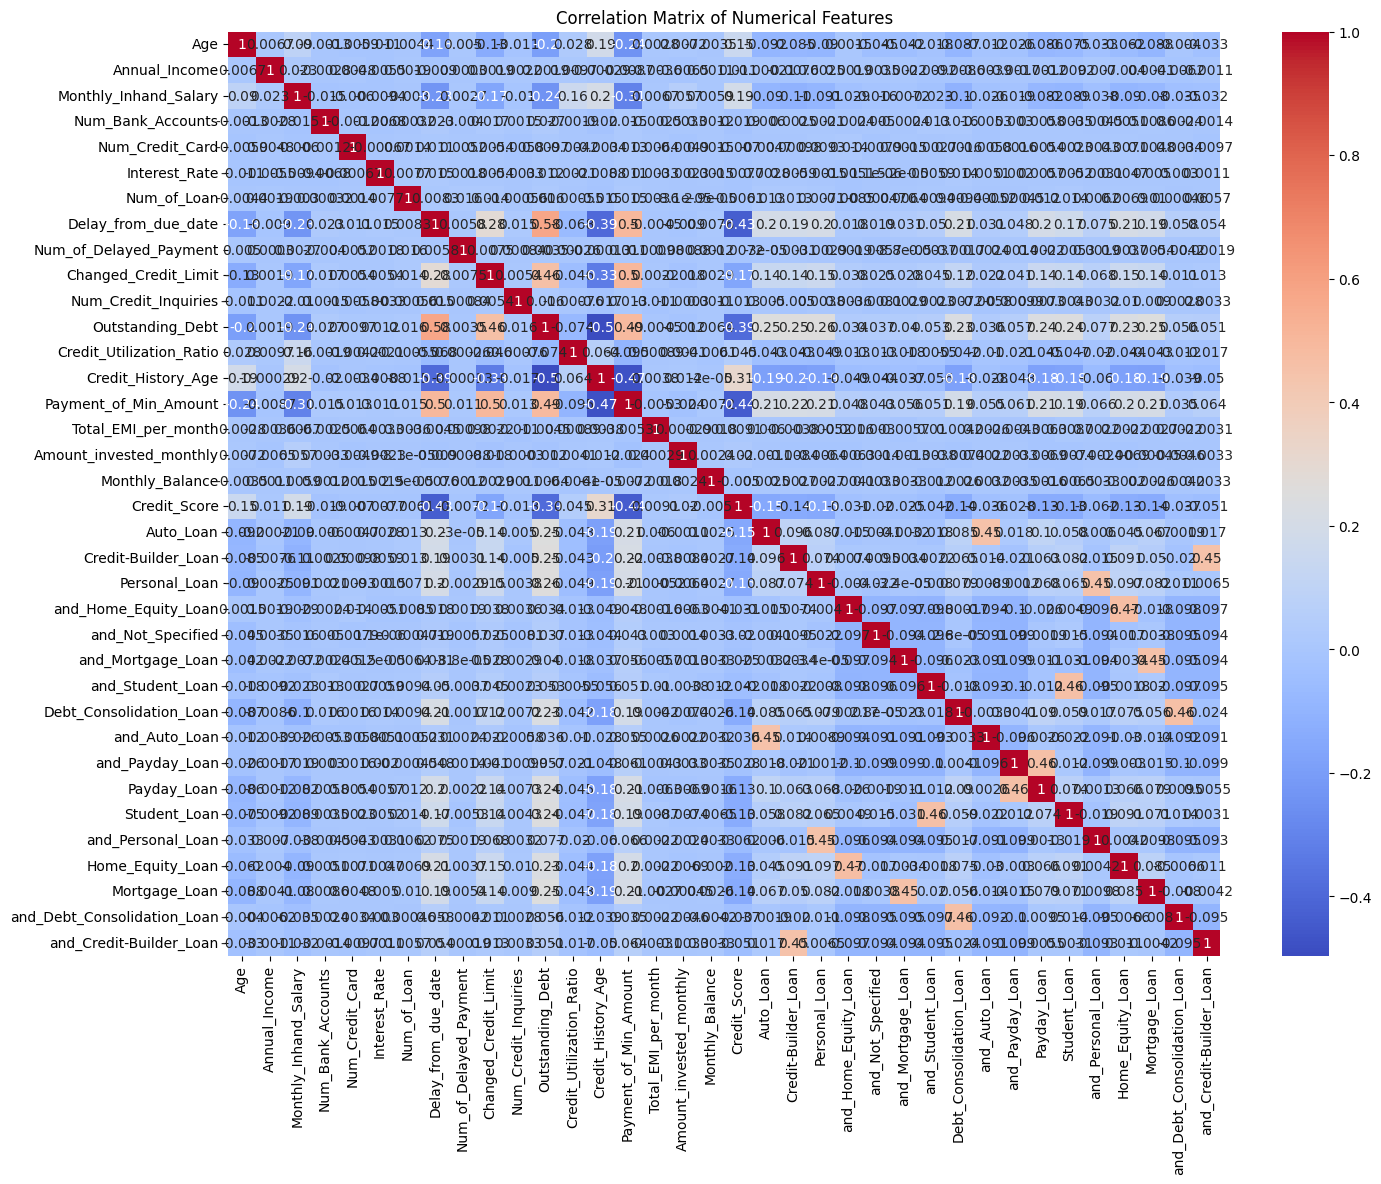

In [78]:
# Correlation Analysis of numerical columns
numerical_df = df.select_dtypes(include=np.number)

correlation_matrix = numerical_df.corr()

plt.figure(figsize = (16,12))
sns.heatmap(correlation_matrix, annot = True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Feature Engineering

In [79]:
# Creating 'Total_Number_of_Accounts' feature
df['Total_Number_of_Accounts'] = df['Num_Bank_Accounts'] + df['Num_Credit_Card']
display(df[['Num_Bank_Accounts', 'Num_Credit_Card', 'Total_Number_of_Accounts']].head())

,Num_Bank_Accounts,Num_Credit_Card,Total_Number_of_Accounts
0,3,4,7
1,3,4,7
2,3,4,7
3,3,4,7
4,3,4,7


In [80]:
# Creating 'Payment to Income Ratio' feature
# Adding a small epsilon to the denominator to avoid division by zero, although describe shows min > 0
df['Payment_to_Income_Ratio'] = df['Total_EMI_per_month'] / (df['Monthly_Inhand_Salary'] + 1e-6)
display(df[['Total_EMI_per_month', 'Monthly_Inhand_Salary', 'Payment_to_Income_Ratio']].head())

,Total_EMI_per_month,Monthly_Inhand_Salary,Payment_to_Income_Ratio
0,49.574949,1824.843333,0.027167
1,49.574949,3091.000000,0.016038
2,49.574949,3091.000000,0.016038
3,49.574949,3091.000000,0.016038
4,49.574949,1824.843333,0.027167


# Train-Test Split

In [81]:
# Create a new DataFrame X by dropping the 'Credit_Score' column
X = df.drop('Credit_Score', axis=1)

# Create a new Series y containing only the 'Credit_Score' column
y = df['Credit_Score']

# Display the first five rows of X
display(X.head())

# Display the first five rows of y
display(y.head())

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Credit_Mix_Standard,Credit_Mix_Unknown,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Total_Number_of_Accounts,Payment_to_Income_Ratio
0,23.0,19114.12,1824.843333,3,4,3,4,3,7.0,11.27,...,False,True,False,False,True,False,False,False,7,0.027167
1,23.0,19114.12,3091.000000,3,4,3,4,-1,19.0,11.27,...,False,False,False,False,False,True,False,False,7,0.016038
2,33.0,19114.12,3091.000000,3,4,3,4,3,7.0,9.31,...,False,False,False,False,False,False,True,False,7,0.016038
3,23.0,19114.12,3091.000000,3,4,3,4,5,4.0,6.27,...,False,False,False,False,False,False,False,True,7,0.016038
4,23.0,19114.12,1824.843333,3,4,3,4,6,19.0,11.27,...,False,False,False,True,False,False,False,False,7,0.027167


,Credit_Score
0,2.0
1,2.0
2,2.0
3,2.0
4,2.0


# Standardization

In [82]:
from sklearn.preprocessing import StandardScaler

# Identify numeric columns to standardize (excluding binary and one-hot encoded columns)
numeric_cols_to_standardize = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
                               'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
                               'Num_of_Delayed_Payment', 'Num_Credit_Inquiries', 'Outstanding_Debt',
                               'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month',
                               'Amount_invested_monthly', 'Monthly_Balance', 'Changed_Credit_Limit', 'Payment_of_Min_Amount', 'Total_Number_of_Accounts', 'Payment_to_Income_Ratio']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train[numeric_cols_to_standardize] = scaler.fit_transform(X_train[numeric_cols_to_standardize])
X_test[numeric_cols_to_standardize] = scaler.transform(X_test[numeric_cols_to_standardize])

# Display the first few rows of the standardized DataFrames
print("\nStandardized X_train:")
display(X_train.head())
print("\nStandardized X_test:")
display(X_test.head())


Standardized X_train:


,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Credit_Mix_Standard,Credit_Mix_Unknown,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Total_Number_of_Accounts,Payment_to_Income_Ratio
9284,0.351362,-0.117087,-1.129213,-0.082930,-0.153692,-0.141874,0.042209,0.488944,-0.080142,0.587612,...,True,False,False,False,False,False,False,True,-0.170803,-0.111708
3668,-0.900139,-0.108684,-0.797789,-0.118027,-0.153692,-0.114781,-0.034981,-0.816508,-0.060427,-0.164263,...,True,False,False,False,True,False,False,False,-0.193728,-0.123517
11105,1.602863,-0.060116,1.072772,-0.091704,-0.131036,-0.126070,0.011333,0.007988,-0.040712,-0.101231,...,True,False,True,False,False,False,False,False,-0.159341,-0.119593
14759,-1.188947,-0.100170,-0.402017,-0.065382,-0.108379,-0.098976,0.057647,1.382148,-0.020997,2.918274,...,False,False,False,False,True,False,False,False,-0.124954,-0.114715
4345,1.314055,-0.071944,0.604779,-0.082930,-0.146140,-0.139617,-0.019543,-0.816508,-0.065356,-0.143252,...,True,False,True,False,False,False,False,False,-0.165072,-0.122384



Standardized X_test:


,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Credit_Mix_Standard,Credit_Mix_Unknown,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Total_Number_of_Accounts,Payment_to_Income_Ratio
19444,1.121516,-0.068006,0.857675,-0.118027,-0.138588,-0.148648,-0.050419,-0.472968,-0.089999,-0.215288,...,False,True,True,False,False,False,False,False,-0.182266,-0.124645
21066,-1.862833,-0.075055,0.485965,-0.091704,-0.146140,-0.117039,0.042209,-0.816508,-0.080142,0.129884,...,True,False,True,False,False,False,False,False,-0.170803,-0.113907
24388,-0.322524,-0.089680,-0.023143,-0.074156,-0.115931,-0.114781,0.026771,0.557652,-0.060427,2.202417,...,False,True,False,False,False,False,False,False,-0.136416,-0.118780
22580,-0.611332,-0.102433,-0.633698,-0.091704,-0.138588,-0.121554,-0.004105,-0.953924,-0.055498,0.083361,...,False,True,False,False,True,False,False,False,-0.165072,-0.117494
27971,-0.322524,0.001681,-0.319240,-0.118027,-0.123483,-0.130585,-0.034981,-1.228756,-0.094928,-2.433394,...,False,False,False,True,False,False,False,False,-0.170803,-0.115608


# Training the Dataset

In [83]:
# Impute remaining missing values with the median in X_train and X_test
for col in X_train.columns:
    if X_train[col].isnull().any():
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        # Impute X_test using the median calculated from X_train
        if col in X_test.columns:
            X_test[col] = X_test[col].fillna(median_val)

# Verify that there are no more missing values
print("NaN values in X_train after imputation:")
display(X_train.isnull().sum().sum())

print("\nNaN values in X_test after imputation:")
display(X_test.isnull().sum().sum())

NaN values in X_train after imputation:


np.int64(0)


NaN values in X_test after imputation:


np.int64(0)

In [84]:
# Impute missing values in y_train and y_test with the mode of y_train
mode_y_train = y_train.mode()[0]
y_train = y_train.fillna(mode_y_train)
y_test = y_test.fillna(mode_y_train)

# Verify that there are no more missing values in y_train and y_test
print("NaN values in y_train after imputation:")
display(y_train.isnull().sum())

print("\nNaN values in y_test after imputation:")
display(y_test.isnull().sum())

NaN values in y_train after imputation:


np.int64(0)


NaN values in y_test after imputation:


np.int64(0)

In [85]:
# Training on Logistic Regression Model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# tTraining on Decission Tree Classifier
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

# Training on Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

print("Models trained successfully.")

Models trained successfully.


# Model Evaluation

In [86]:
# Predictions on the test data
y_pred_log_reg = log_reg.predict(X_test)
y_pred_dt_clf = dt_clf.predict(X_test)
y_pred_rf_clf = rf_clf.predict(X_test)

# Logistic Regression Evaluation
print('Logistic Regression Evaluation:')
print('Accuracy:', accuracy_score(y_test, y_pred_log_reg))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_log_reg))
print('Classification Report:\n', classification_report(y_test, y_pred_log_reg))
print('-'* 55)

# Decision Tree Classifier Evaluation
print('Decision Tree Classifier Evaluation:')
print('Accuracy:', accuracy_score(y_test, y_pred_dt_clf))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_dt_clf))
print('Classification Report:\n', classification_report(y_test, y_pred_dt_clf))
print('-'* 55)

# Random Forest Classifier Evaluation
print('Random Forest Classifier Evaluation:')
print('Accuracy:', accuracy_score(y_test, y_pred_rf_clf))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_rf_clf))
print('Classification Report:\n', classification_report(y_test, y_pred_rf_clf))

Logistic Regression Evaluation:
Accuracy: 0.6186872840927784
Confusion Matrix:
 [[ 811  823  108]
 [ 507 2356  380]
 [  50  450  594]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.59      0.47      0.52      1742
         1.0       0.65      0.73      0.69      3243
         2.0       0.55      0.54      0.55      1094

    accuracy                           0.62      6079
   macro avg       0.60      0.58      0.58      6079
weighted avg       0.62      0.62      0.61      6079

-------------------------------------------------------
Decision Tree Classifier Evaluation:
Accuracy: 0.6961671327520974
Confusion Matrix:
 [[1189  515   38]
 [ 534 2365  344]
 [  57  359  678]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.67      0.68      0.68      1742
         1.0       0.73      0.73      0.73      3243
         2.0       0.64      0.62      0.63      1094

    accuracy          

# Hyperparameter Tuning (Random Forest)

In [87]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid for RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_features': ['sqrt', 'log2'],  # Number of features to consider at every split
    'max_depth': [10, 20, 30, None],  # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required at each leaf node
    'bootstrap': [True, False] # Method of selecting samples for training each tree
}

# Initialize RandomizedSearchCV
# We'll use n_iter=50 for a reasonable number of iterations, but this can be adjusted
rf_random = RandomizedSearchCV(estimator=rf_clf, param_distributions=param_grid,
                               n_iter=50, cv=3, verbose=2, random_state=42, n_jobs=-1)

# Fit the random search model
rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, verbose=2)

# Evaluate Tuned Random Forest Model

In [88]:
# Get the best model from the random search
best_rf_clf = rf_random.best_estimator_

# Make predictions with the best model
y_pred_best_rf = best_rf_clf.predict(X_test)

# Evaluate the best model
print("Tuned Random Forest Classifier Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_best_rf))

Tuned Random Forest Classifier Evaluation:
Accuracy: 0.8007896035532159
Confusion Matrix:
 [[1422  315    5]
 [ 405 2631  207]
 [   2  277  815]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.78      0.82      0.80      1742
         1.0       0.82      0.81      0.81      3243
         2.0       0.79      0.74      0.77      1094

    accuracy                           0.80      6079
   macro avg       0.80      0.79      0.79      6079
weighted avg       0.80      0.80      0.80      6079

